# XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import xgboost as xgb
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


In [6]:
# Convert sparse matrices to dense for XGBoost
X_train_dense = X_train_tfidf.astype(np.float32)
X_test_dense = X_test_tfidf.astype(np.float32)
# Convert [1, 2] labels to [0, 1]
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1

## 5: XGBoost Model Training

In [7]:
# Train XGBoost Classifier
print("Training XGBoost Classifier...")
start_time = time.time()
xgb_classifier = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    min_child_weight=1,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_classifier.fit(
    X_train_dense, y_train,
    verbose=False,
    sample_weight=None
)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training XGBoost Classifier...
Training completed in 391.2421 seconds


## 6: Model Evaluation

In [8]:
# Make predictions
y_pred = xgb_classifier.predict(X_test_dense)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("XGBOOST CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

XGBOOST CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8321
Precision: 0.8227
Recall:    0.8481
F1-Score:  0.8352
Training Time: 391.2421 seconds


## 7: Classification Report

In [9]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      9966
    Positive       0.82      0.85      0.84     10034

    accuracy                           0.83     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.83      0.83      0.83     20000



## 8: Confusion Matrix Visualization

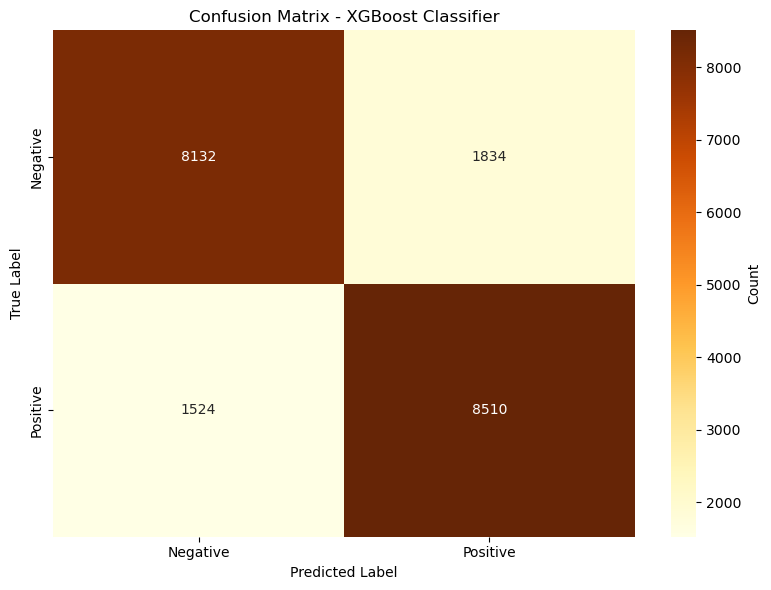

Confusion Matrix:
[[8132 1834]
 [1524 8510]]

True Negatives: 8132
False Positives: 1834
False Negatives: 1524
True Positives: 8510


In [10]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - XGBoost Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## 9: Feature Importance

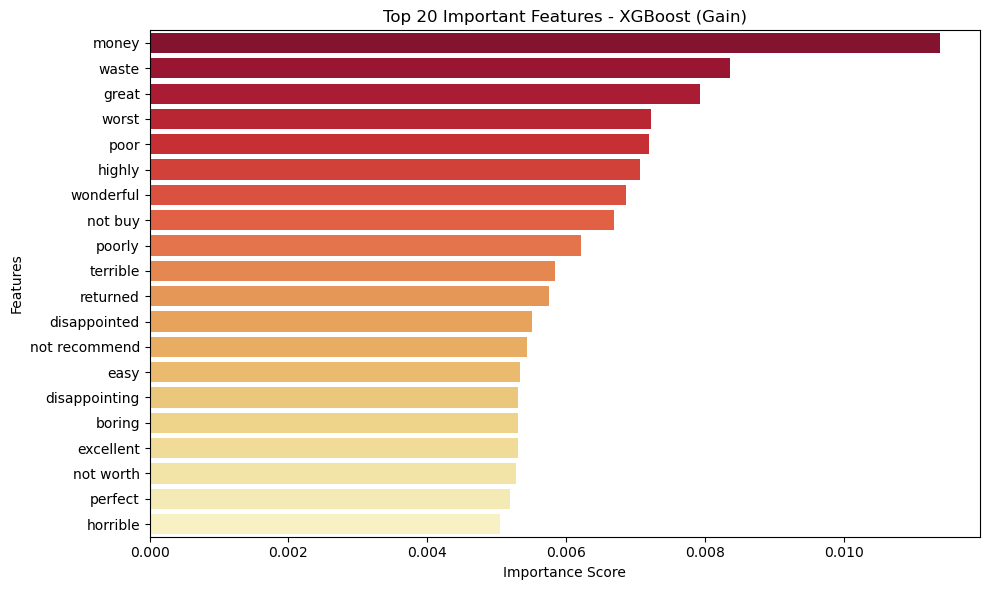


Top 20 Important Features:
      feature  importance
        money    0.011392
        waste    0.008364
        great    0.007935
        worst    0.007227
         poor    0.007193
       highly    0.007064
    wonderful    0.006868
      not buy    0.006688
       poorly    0.006209
     terrible    0.005846
     returned    0.005751
 disappointed    0.005514
not recommend    0.005438
         easy    0.005340
disappointing    0.005312
       boring    0.005311
    excellent    0.005308
    not worth    0.005277
      perfect    0.005189
     horrible    0.005047


In [11]:
# Get feature importance using gain (contributes most to model performance)
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = xgb_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='YlOrRd_r')
plt.title('Top 20 Important Features - XGBoost (Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## 10: Learning Curve Analysis

In [12]:
# Get feature importance by different metrics
results = xgb_classifier.get_booster().get_score(importance_type='weight')
print(f"Number of times features are used in splits: {len(results)}")
print(f"\nTop 10 features by split count (weight):")
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)[:10]
for feature, count in sorted_results:
    print(f"  {feature}: {count}")

Number of times features are used in splits: 1024

Top 10 features by split count (weight):
  f57594: 300.0
  f12797: 248.0
  f36547: 100.0
  f9409: 90.0
  f98265: 84.0
  f49105: 78.0
  f35210: 74.0
  f46804: 65.0
  f7852: 59.0
  f61026: 59.0


## 11: Model Summary

In [13]:
print("XGBOOST MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Number of Estimators: {xgb_classifier.n_estimators}")
print(f"  - Max Depth: {xgb_classifier.max_depth}")
print(f"  - Learning Rate: {xgb_classifier.learning_rate}")
print(f"  - Subsample: {xgb_classifier.subsample}")
print(f"  - Colsample by Tree: {xgb_classifier.colsample_bytree}")
print(f"  - Gamma: {xgb_classifier.gamma}")
print(f"  - Min Child Weight: {xgb_classifier.min_child_weight}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")
print(f"\nModel Characteristics:")
print(f"  - Booster Type: gbtree")
print(f"  - Tree Method: auto")
print(f"  - Objective: binary:logistic")

XGBOOST MODEL SUMMARY

Model Parameters:
  - Number of Estimators: 200
  - Max Depth: 6
  - Learning Rate: 0.1
  - Subsample: 0.8
  - Colsample by Tree: 0.8
  - Gamma: 0
  - Min Child Weight: 1

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8321
  - Precision: 0.8227
  - Recall:    0.8481
  - F1-Score:  0.8352
  - Training Time: 391.2421 seconds

Model Characteristics:
  - Booster Type: gbtree
  - Tree Method: auto
  - Objective: binary:logistic


## Saving the Model and Pipeline

In [14]:
save(model_base='data/models', model=xgb_classifier, model_name='12_xgboost_classifier.joblib')

Saved model 12_xgboost_classifier.joblib to data/models/12_xgboost_classifier.joblib


{'model': PosixPath('data/models/12_xgboost_classifier.joblib')}